# 🔍 ETS Decomposition (Error-Trend-Seasonality):

**ETS Decomposition** is a statistical method that deconstructs a time series into three distinct components to help us understand the underlying patterns.

The acronym stands for:
* **E**rror (often called "Residual" or "Noise")
* **T**rend
* **S**easonality

When we decompose a signal, we are essentially asking: *"If I remove the Trend and the Seasonality, what is left?"* The answer is the Error (Residual).


## The Two Main Models

The most important decision you make when decomposing is choosing how these components interact. Do they **add** together, or do they **multiply**?

### 1. Additive Model
**Formula:**
$$y_t = \text{Trend}_t + \text{Seasonality}_t + \text{Error}_t$$

**When to use:**
* When the seasonal variations are roughly **constant** over time.
* The peaks and troughs of the cycles stay the same height, regardless of whether the trend is going up or down.
* *Analogy:* A person walking up a hill (Trend) while bouncing a ball (Seasonality). The ball bounces the same height (1 meter) whether they are at the bottom or the top of the hill.

### 2. Multiplicative Model
**Formula:**
$$y_t = \text{Trend}_t \times \text{Seasonality}_t \times \text{Error}_t$$

**When to use:**
* When the seasonal variations **change** relative to the trend.
* The data shows a "funnel" shape: as the trend increases, the seasonality swings get wider and taller.
* *Analogy:* A standard "Compound Growth" curve. If sales are 10% higher in December, that "10%" represents a much larger dollar amount when the company is big vs. when it was small.

---

## ⚡ How to Decide (Visual Test)

Look at your raw data plot:

| Visual Feature | Model Choice |
| :--- | :--- |
| **Seasonality Height:** Constant | **Additive** |
| **Seasonality Height:** Growing/Shrinking | **Multiplicative** |
| **Trend:** Linear (Straight line) | **Additive** |
| **Trend:** Exponential (Curved) | **Multiplicative** |

> **Note on Zero/Negative Values:** Multiplicative models often fail if your data contains zeros or negative numbers (because you can't divide by zero during the math). In those cases, you must stick to Additive or log-transform your data first.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

#### 2) Creating Synthetic Data (Multiplicative Nature):

In [4]:
# Dates for Data:

dates = pd.date_range(start= '2020-01-01', periods= 120, freq= 'ME')

In [5]:
# Trend of Data:

trend = np.linspace(start= 10, stop= 50, num= 120)

In [7]:
# Seasonality of Data (Multiplicative):

seasonality = np.sin(np.linspace(start= 0, stop= 20, num= 120)) * (trend * 0.5)

In [10]:
# Final Data:
# data = trend + seasonality + error (noise)

data = trend + seasonality + np.random.normal(loc= 0, scale= 3, size= 120)
df = pd.DataFrame({'Sales': data}, index= dates)

In [11]:
df

,Sales
2020-01-31,10.795895
2020-02-29,5.838885
2020-03-31,12.694829
2020-04-30,10.436220
2020-05-31,22.412488
...,...
2029-08-31,64.108018
2029-09-30,65.207477
2029-10-31,67.253827
2029-11-30,69.844628


<Axes: >

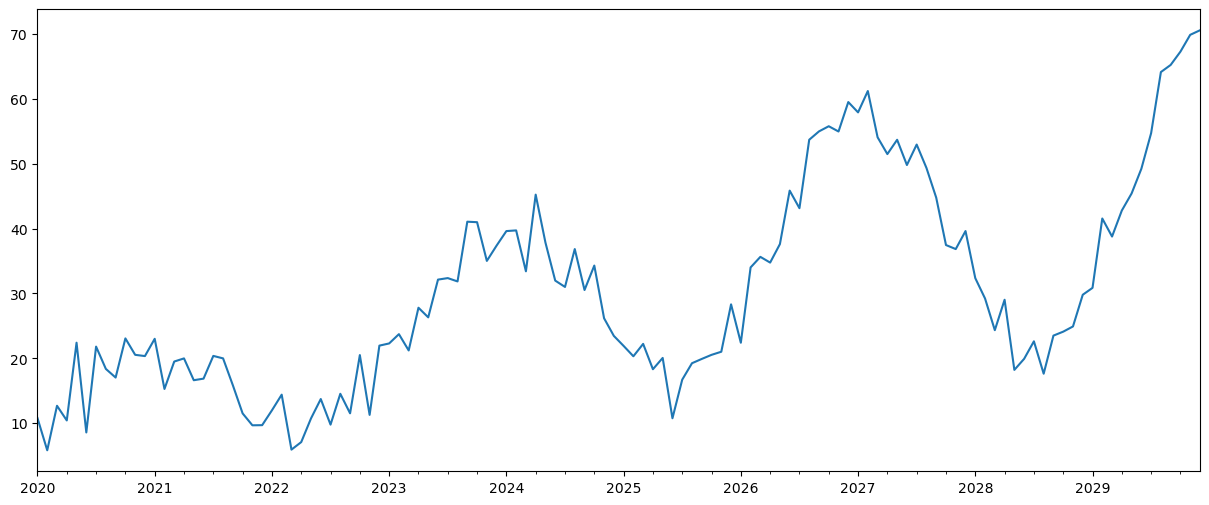

In [13]:
# Plotting Data:

df['Sales'].plot(kind= 'line', figsize= (15,6))

#### 3) Decomposing The Data:

In [14]:
result = seasonal_decompose(x= df['Sales'], model= 'multiplicative', period= 12)

<Figure size 1500x800 with 0 Axes>

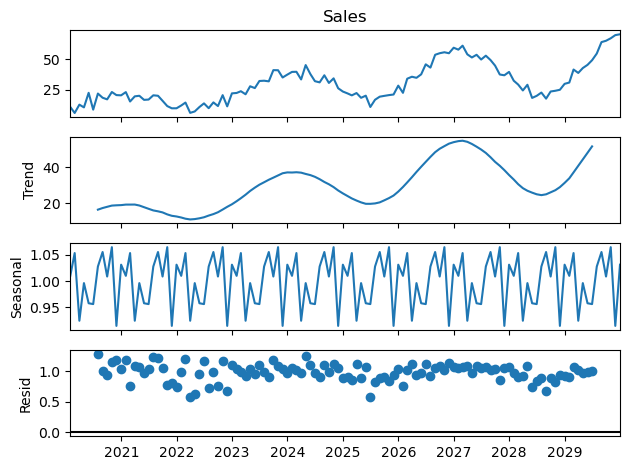

In [15]:
# Plotting Decomposition Results:

plt.figure(figsize= (15,8))
result.plot()
plt.show()

#### 4) Creating DataFrame of Different Time Series Components:

In [16]:
decomp_df = pd.DataFrame({'Trend': result.trend,
                         'Seasonality': result.seasonal,
                         'Error(Noise)': result.resid},
                        index= dates)

In [18]:
decomp_df

,Trend,Seasonality,Error(Noise)
2020-01-31,NaN,1.009983,NaN
2020-02-29,NaN,1.053311,NaN
2020-03-31,NaN,0.924502,NaN
2020-04-30,NaN,0.996181,NaN
2020-05-31,NaN,0.957784,NaN
...,...,...,...
2029-08-31,NaN,1.055312,NaN
2029-09-30,NaN,1.008619,NaN
2029-10-31,NaN,1.064539,NaN
2029-11-30,NaN,0.914693,NaN


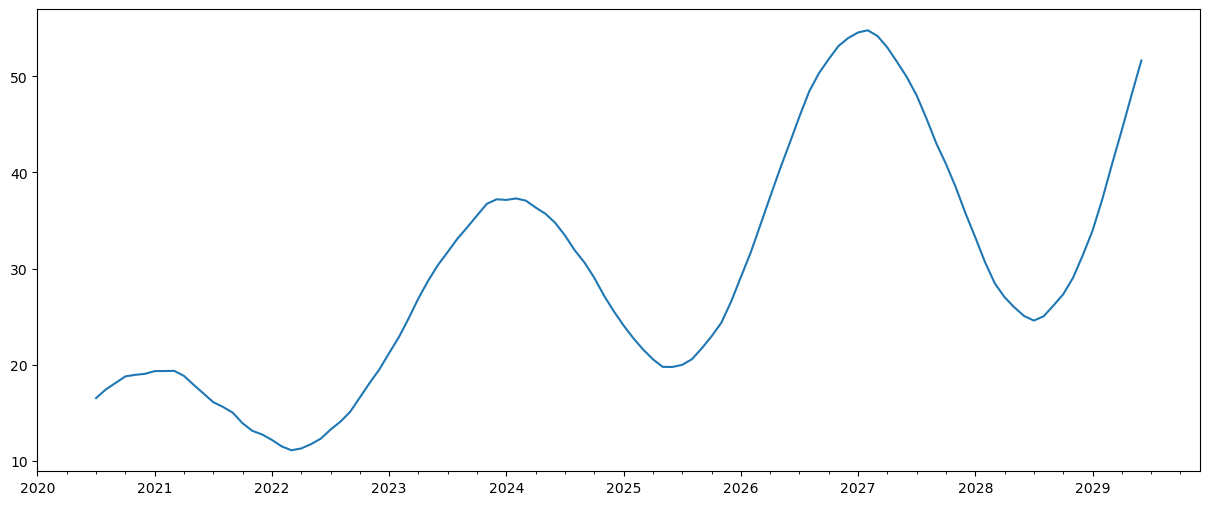

In [21]:
# Plotting Trend:

decomp_df['Trend'].plot(kind= 'line', figsize= (15,6))
plt.show()

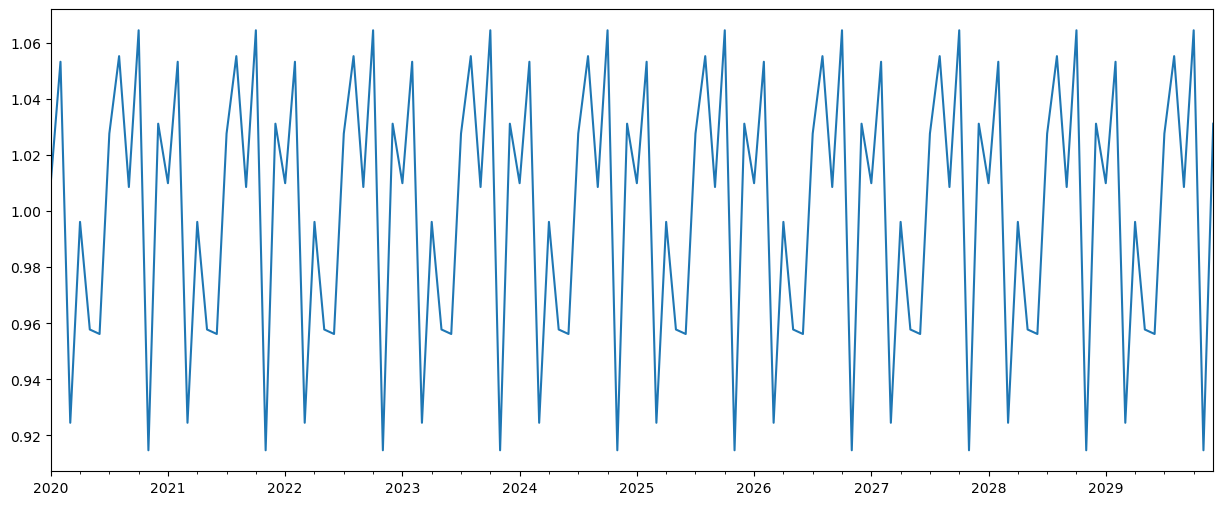

In [22]:
# Plotting Seasonality:

decomp_df['Seasonality'].plot(kind= 'line', figsize= (15,6))
plt.show()

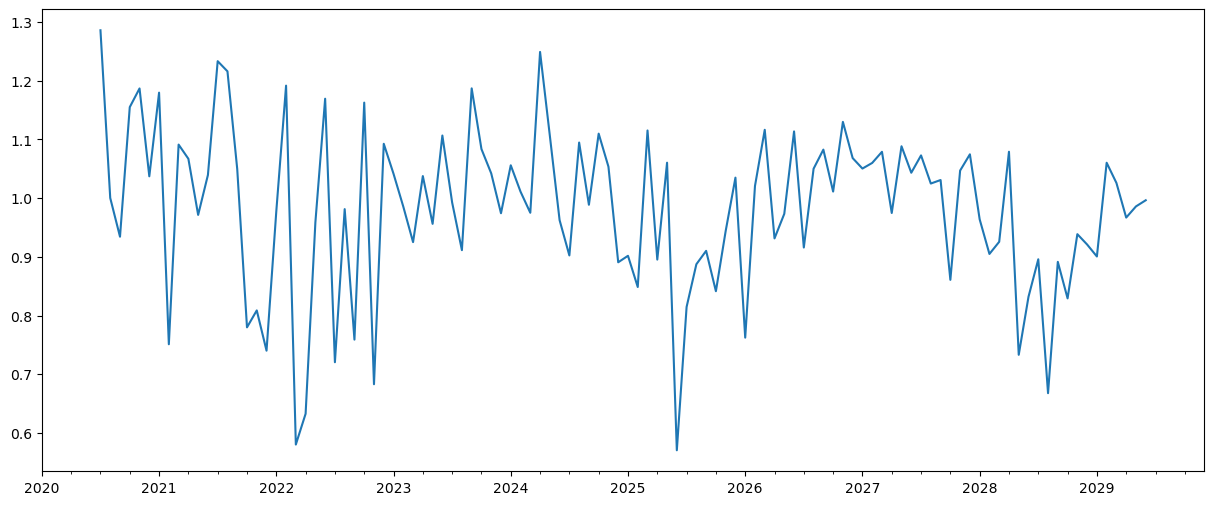

In [23]:
# Plotting Error:

decomp_df['Error(Noise)'].plot(kind= 'line', figsize= (15,6))
plt.show()